In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("Kompilasi Data 1.xlsx")

In [4]:
df.shape

(38, 12)

In [5]:
df.head()

,Provinsi,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,jumlah_UMKM_Nonpertanian,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
0,Aceh,74.03,99.416552,40.01,37.65,108507,624542,5086801,75.99,5.12,198.69,0.99
1,Sumatera Utara,74.02,96.515622,36.27,35.38,123911,1485080,7957689,73.15,2.72,172.37,4.06
2,Sumatera Barat,74.49,98.445998,42.26,28.75,88053,740347,4567033,75.14,5.56,194.63,3.08
3,Riau,74.79,98.556150,36.58,36.93,54425,580624,3494581,82.49,2.57,156.56,5.66
4,Jambi,73.43,98.802018,33.54,33.90,31268,344836,2065021,85.91,3.65,150.80,4.12


In [6]:
df.tail()

,Provinsi,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,jumlah_UMKM_Nonpertanian,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
33,Papua Barat Daya,68.63,91.950758,NaN,24.68,2861,51425,272521,74.43,5.26,156.89,2.57
34,Papua,73.00,83.764940,33.69,23.29,7499,44768,398165,74.11,7.02,172.14,11.27
35,Papua Selatan,67.90,88.840580,NaN,28.98,4931,17734,363652,73.21,2.91,236.01,1.29
36,Papua Tengah,59.75,44.700855,NaN,28.78,3828,30938,290986,73.28,0.56,156.26,1.75
37,Papua Pegunungan,53.42,43.850688,NaN,2.70,587,1859,51030,57.30,2.89,151.42,0.00


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Provinsi                  38 non-null     object 
 1   IPM                       38 non-null     float64
 2   Infrastruktur_Desa        38 non-null     float64
 3   IMDI                      34 non-null     float64
 4   Persen_Ecommerce          38 non-null     float64
 5   Jumlah_UMKM               38 non-null     int64  
 6   jumlah_UMKM_Nonpertanian  38 non-null     int64  
 7   nilai_tambah              38 non-null     int64  
 8   Penetrasi_Internet        38 non-null     float64
 9   Pelatihan_TIK             38 non-null     float64
 10  Level_TIK                 38 non-null     float64
 11  Pembayaran_Digital        38 non-null     float64
dtypes: float64(8), int64(3), object(1)
memory usage: 3.7+ KB


In [8]:
#finding missing value
df.isnull().sum()

Provinsi                    0
IPM                         0
Infrastruktur_Desa          0
IMDI                        4
Persen_Ecommerce            0
Jumlah_UMKM                 0
jumlah_UMKM_Nonpertanian    0
nilai_tambah                0
Penetrasi_Internet          0
Pelatihan_TIK               0
Level_TIK                   0
Pembayaran_Digital          0
dtype: int64

In [9]:
df.isnull().sum()/df.shape[0]*100

Provinsi                     0.000000
IPM                          0.000000
Infrastruktur_Desa           0.000000
IMDI                        10.526316
Persen_Ecommerce             0.000000
Jumlah_UMKM                  0.000000
jumlah_UMKM_Nonpertanian     0.000000
nilai_tambah                 0.000000
Penetrasi_Internet           0.000000
Pelatihan_TIK                0.000000
Level_TIK                    0.000000
Pembayaran_Digital           0.000000
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#identify garbage value (ngecek kemungkinan adanya typo atau rare nilai yg tidak sesuai dgn konsep data)
for col in df.select_dtypes(include="object").columns:
    print(f"\nColumn: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print("Top values:")
    print(df[col].value_counts().head(10))
    print("Rare values:")
    print(df[col].value_counts()[df[col].value_counts() <= 2].head(20))
    print("-" * 50)


Column: Provinsi
Unique values: 38
Top values:
Provinsi
Aceh                    1
Sumatera Utara          1
Sumatera Barat          1
Riau                    1
Jambi                   1
Sumatera Selatan        1
Bengkulu                1
Lampung                 1
Kep. Bangka Belitung    1
Kepulauan Riau          1
Name: count, dtype: int64
Rare values:
Provinsi
Aceh                    1
Sumatera Utara          1
Sumatera Barat          1
Riau                    1
Jambi                   1
Sumatera Selatan        1
Bengkulu                1
Lampung                 1
Kep. Bangka Belitung    1
Kepulauan Riau          1
DKI Jakarta             1
Jawa Barat              1
Jawa Tengah             1
D.I. Yogyakarta         1
Jawa Timur              1
Banten                  1
Bali                    1
Nusa Tenggara Barat     1
Nusa Tenggara Timur     1
Kalimantan Barat        1
Name: count, dtype: int64
--------------------------------------------------


In [12]:
df.describe()

,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,jumlah_UMKM_Nonpertanian,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
count,38.000000,38.000000,34.000000,38.000000,38.000000,3.800000e+01,3.800000e+01,38.000000,38.000000,38.000000,38.000000
mean,72.388421,94.329776,37.999706,35.194474,116143.289474,7.949755e+05,7.301559e+06,75.233158,3.950789,178.023158,4.795526
std,5.150227,12.594180,5.751563,11.993417,215817.567688,1.258747e+06,1.336654e+07,8.370254,1.470327,33.729680,5.114648
min,53.420000,43.850688,20.900000,2.700000,587.000000,1.859000e+03,5.103000e+04,57.300000,0.560000,122.320000,0.000000
25%,71.080000,94.998290,33.865000,28.757500,20746.750000,1.922848e+05,1.024709e+06,69.277500,2.790000,154.947500,2.470000
50%,73.180000,98.708625,37.605000,36.155000,49199.000000,3.415470e+05,3.203949e+06,74.880000,3.855000,170.945000,3.320000
75%,74.345000,99.770628,43.025000,42.222500,106311.750000,7.176338e+05,6.088314e+06,82.247500,5.027500,197.730000,4.800000
max,83.080000,100.000000,47.980000,63.540000,925985.000000,5.429638e+06,5.769454e+07,88.730000,7.460000,257.820000,28.610000


In [13]:
df.describe(include="object")

,Provinsi
count,38
unique,38
top,Aceh
freq,1


handling missing value pake KNN


In [14]:
from sklearn.impute import KNNImputer

# Cek provinsi yang missing
print("Provinsi dengan missing value:")
print(df[df.isnull().any(axis=1)]['Provinsi'].tolist())

# Pisahkan kolom provinsi
provinsi = df['Provinsi'].copy()
df_num = df.drop(columns=['Provinsi'])

# KNN Imputation
imputer = KNNImputer(n_neighbors=3)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_num),
    columns=df_num.columns
)
df_imputed.insert(0, 'Provinsi', provinsi.values)

print(f"\nMissing value setelah imputasi: {df_imputed.isnull().sum().sum()}")
print("\nNilai IMDI hasil imputasi:")
df_imputed[df_imputed['Provinsi'].isin([
    'Papua Barat Daya','Papua Selatan','Papua Tengah','Papua Pegunungan'
])][['Provinsi','IMDI']]

Provinsi dengan missing value:
['Papua Barat Daya', 'Papua Selatan', 'Papua Tengah', 'Papua Pegunungan']

Missing value setelah imputasi: 0

Nilai IMDI hasil imputasi:


,Provinsi,IMDI
33,Papua Barat Daya,35.296667
35,Papua Selatan,35.296667
36,Papua Tengah,35.296667
37,Papua Pegunungan,35.296667


In [ ]:
df_num_imp = df_imputed.drop(columns=['Provinsi'])

cols = df_num_imp.columns
n_cols = 3
n_rows = -(-len(cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df_num_imp[col], patch_artist=True,
                    boxprops=dict(facecolor='#4C9F38', alpha=0.6))
    axes[i].set_title(col, fontsize=9, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier per Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

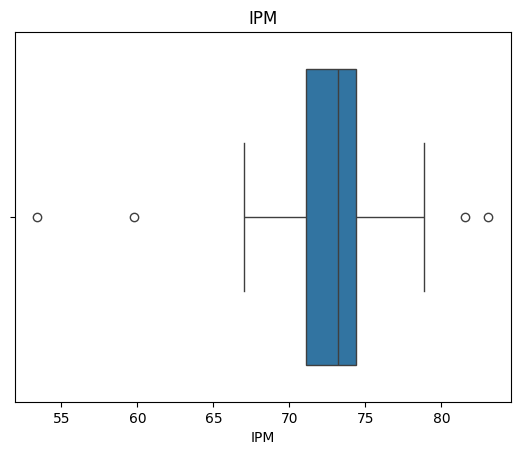

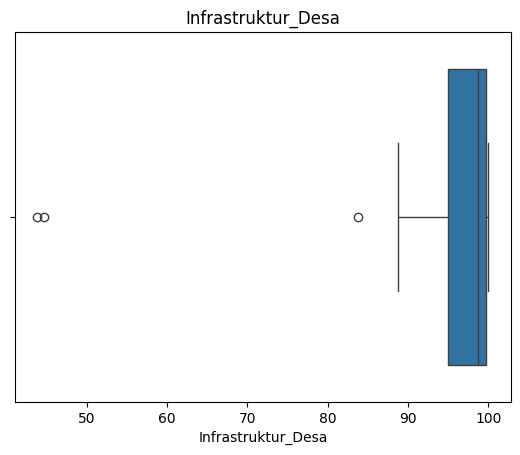

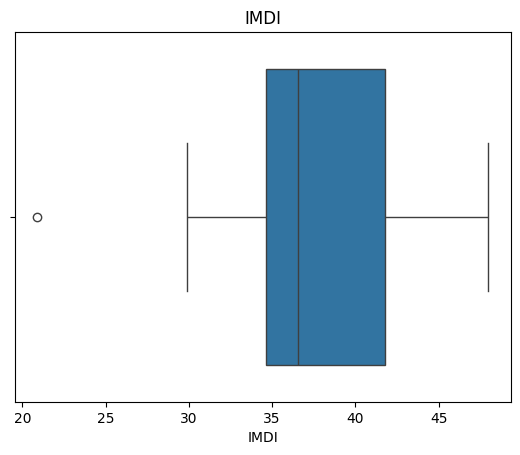

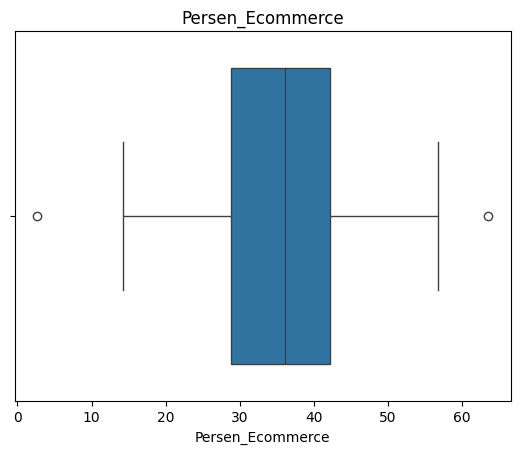

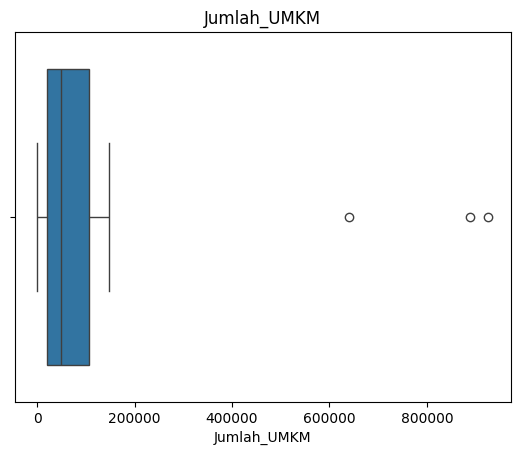

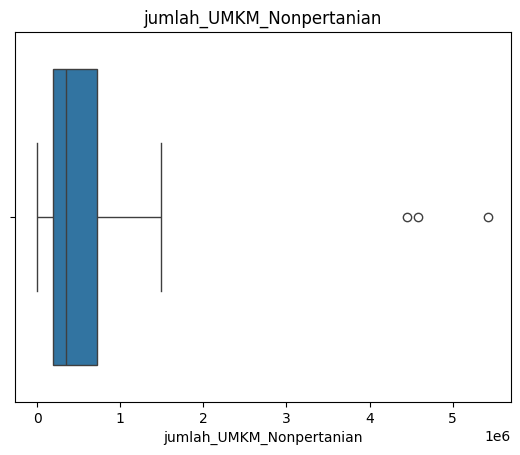

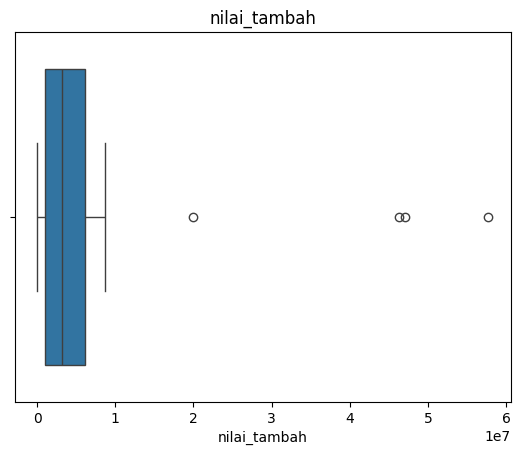

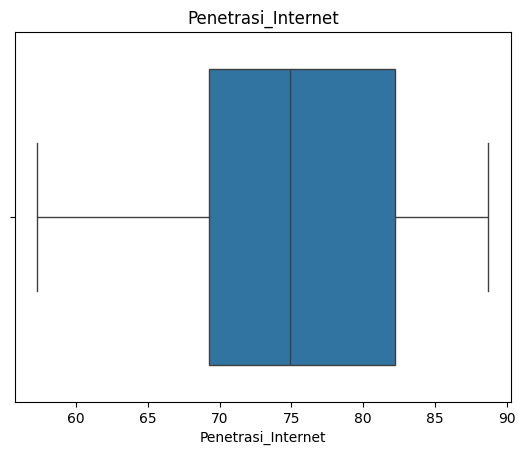

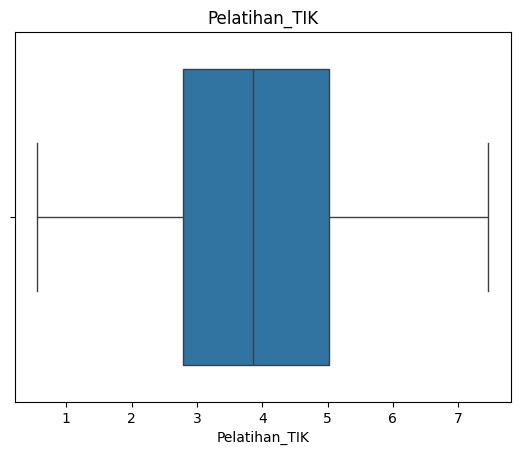

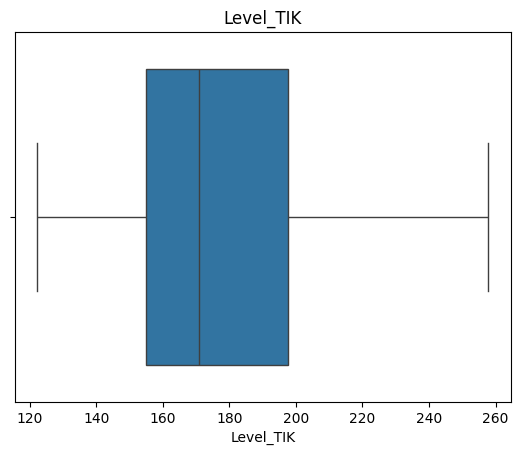

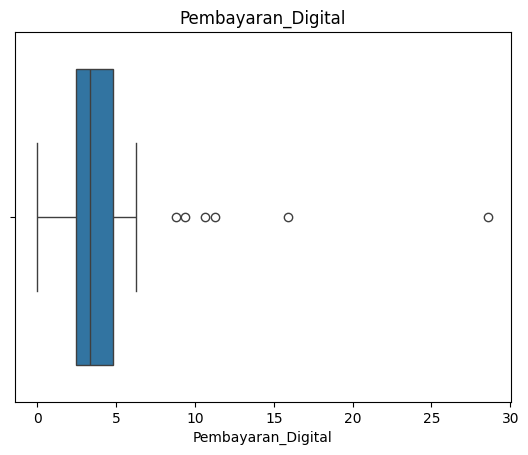

In [15]:
import warnings
warnings.filterwarnings("ignore")

for i in df_imputed.select_dtypes(include="number").columns:
    sns.boxplot(data=df_imputed, x=i)
    plt.title(i)
    plt.show()

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Pisahkan kolom provinsi
provinsi = df_imputed['Provinsi'].copy()
df_num_imp = df_imputed.drop(columns=['Provinsi'])

# Normalisasi
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_num_imp),
    columns=df_num_imp.columns
)
df_scaled.insert(0, 'Provinsi', provinsi.values)

print("✅ Normalisasi selesai — semua variabel dalam rentang [0, 1]")
print(f"Shape data: {df_scaled.shape}")
df_scaled.drop(columns=['Provinsi']).describe().round(3)

✅ Normalisasi selesai — semua variabel dalam rentang [0, 1]
Shape data: (38, 12)


,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,jumlah_UMKM_Nonpertanian,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
count,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000
mean,0.640,0.899,0.621,0.534,0.125,0.146,0.126,0.571,0.491,0.411,0.168
std,0.174,0.224,0.203,0.197,0.233,0.232,0.232,0.266,0.213,0.249,0.179
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.595,0.911,0.507,0.428,0.022,0.035,0.017,0.381,0.323,0.241,0.086
50%,0.666,0.977,0.577,0.550,0.053,0.063,0.055,0.559,0.478,0.359,0.116
75%,0.705,0.996,0.772,0.650,0.114,0.132,0.105,0.794,0.647,0.557,0.168
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


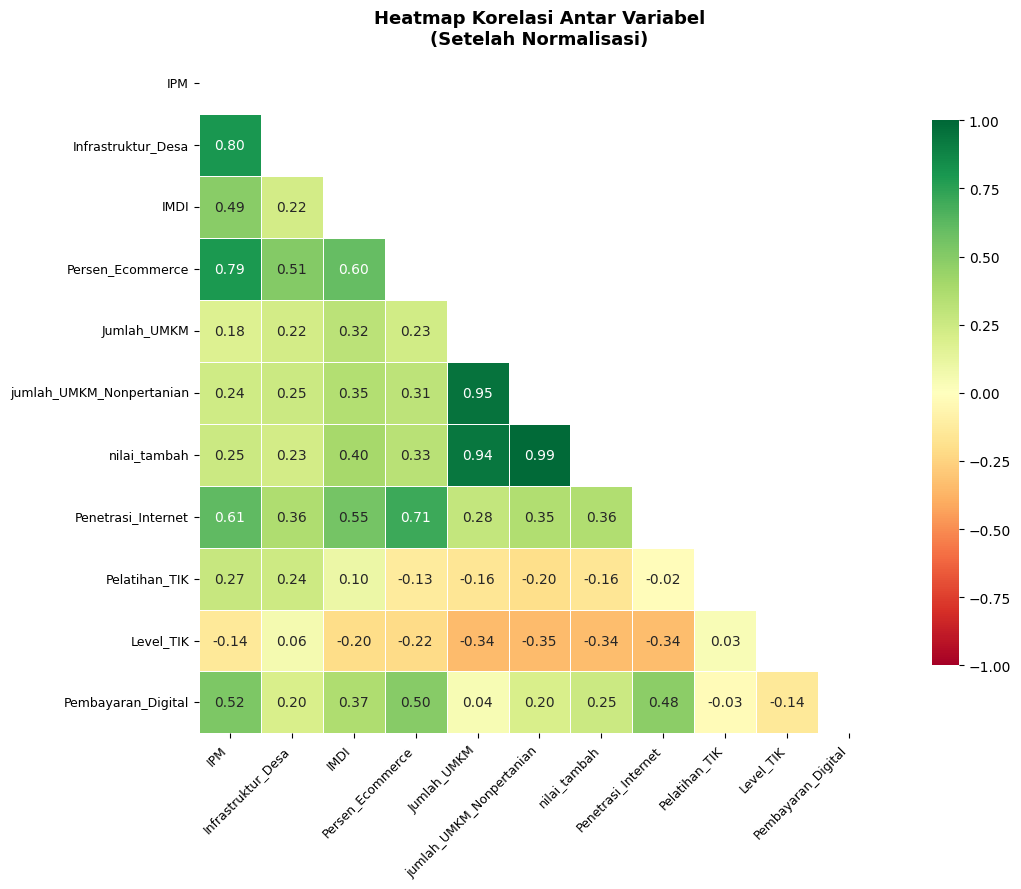


Pasangan variabel dengan korelasi > 0.85:
  Jumlah_UMKM & jumlah_UMKM_Nonpertanian: r = 0.947
  Jumlah_UMKM & nilai_tambah: r = 0.937
  jumlah_UMKM_Nonpertanian & nilai_tambah: r = 0.986


In [ ]:
corr = df_scaled.drop(columns=['Provinsi']).corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Heatmap Korelasi Antar Variabel\n(Setelah Normalisasi)',
        fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Tampilkan pasangan korelasi tinggi
print("\nPasangan variabel dengan korelasi > 0.85:")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i,j], 3)))

if high_corr:
    for h in high_corr:
        print(f"  {h[0]} & {h[1]}: r = {h[2]}")
else:
    print("  Tidak ada ✅")

In [20]:
# Drop jumlah_UMKM_Nonpertanian karena subset dari Jumlah_UMKM
df_final = df_scaled.drop(columns=['jumlah_UMKM_Nonpertanian'])

print(f"Variabel sebelum drop : {df_scaled.shape[1]-1}")
print(f"Variabel setelah drop : {df_final.shape[1]-1}")
print(f"\nVariabel final:")
for col in df_final.drop(columns=['Provinsi']).columns.tolist():
    print(f"  - {col}")

Variabel sebelum drop : 11
Variabel setelah drop : 10

Variabel final:
  - IPM
  - Infrastruktur_Desa
  - IMDI
  - Persen_Ecommerce
  - Jumlah_UMKM
  - nilai_tambah
  - Penetrasi_Internet
  - Pelatihan_TIK
  - Level_TIK
  - Pembayaran_Digital


In [21]:
from sklearn.decomposition import PCA
import numpy as np

# Siapkan data tanpa kolom Provinsi
X = df_final.drop(columns=['Provinsi']).values
provinsi_label = df_final['Provinsi'].values

print(f"Shape data input PCA: {X.shape}")
print(f"(38 provinsi × 10 variabel)")

Shape data input PCA: (38, 10)
(38 provinsi × 10 variabel)


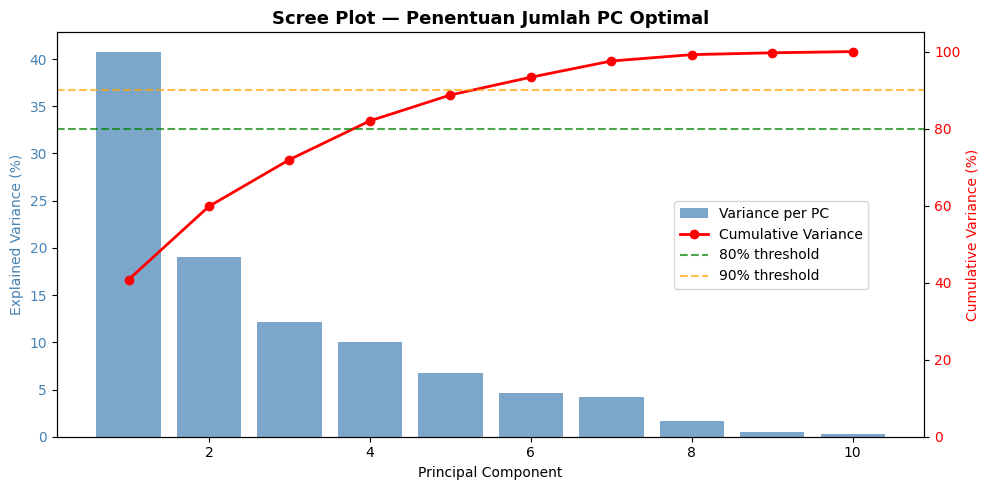


Variance Explained per PC:
PC      Variance (%)  Cumulative (%)
------------------------------------
PC1            40.79           40.79
PC2            19.03           59.82
PC3            12.12           71.95
PC4            10.07           82.01
PC5             6.72           88.73
PC6             4.62           93.35
PC7             4.20           97.55
PC8             1.66           99.21
PC9             0.48           99.69
PC10            0.31          100.00


In [22]:
# Fit PCA dengan semua komponen dulu
pca_full = PCA()
pca_full.fit(X)

# Hitung variance explained
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart variance per PC
ax1.bar(range(1, len(explained_var)+1), explained_var * 100,
        color='steelblue', alpha=0.7, label='Variance per PC')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
         'ro-', linewidth=2, markersize=6, label='Cumulative Variance')
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

plt.title('Scree Plot — Penentuan Jumlah PC Optimal', fontsize=13, fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.88, 0.5))
plt.tight_layout()
plt.show()

# Print tabel variance
print("\nVariance Explained per PC:")
print(f"{'PC':<6} {'Variance (%)':>13} {'Cumulative (%)':>15}")
print("-" * 36)
for i, (var, cum) in enumerate(zip(explained_var * 100, cumulative_var * 100)):
    print(f"PC{i+1:<4} {var:>13.2f} {cum:>15.2f}")

In [23]:
# Pilih PC yang mencapai minimal 80% cumulative variance
n_components = np.argmax(cumulative_var >= 0.80) + 1
print(f"Jumlah PC optimal (≥80% variance): {n_components}")

# Fit PCA
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

print(f"\nShape setelah PCA: {X_pca.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Jumlah PC optimal (≥80% variance): 4

Shape setelah PCA: (38, 4)
Total variance explained: 82.01%


Loading Matrix (kontribusi variabel ke tiap PC):
                      PC1    PC2    PC3    PC4
IPM                 0.297 -0.314  0.104  0.064
Infrastruktur_Desa  0.277 -0.357  0.476  0.101
IMDI                0.315 -0.079 -0.074 -0.029
Persen_Ecommerce    0.356 -0.213 -0.106 -0.229
Jumlah_UMKM         0.333  0.500  0.383  0.036
nilai_tambah        0.372  0.442  0.324 -0.033
Penetrasi_Internet  0.497 -0.194 -0.336 -0.117
Pelatihan_TIK      -0.008 -0.314  0.205  0.758
Level_TIK          -0.259 -0.341  0.554 -0.559
Pembayaran_Digital  0.214 -0.154 -0.179 -0.168


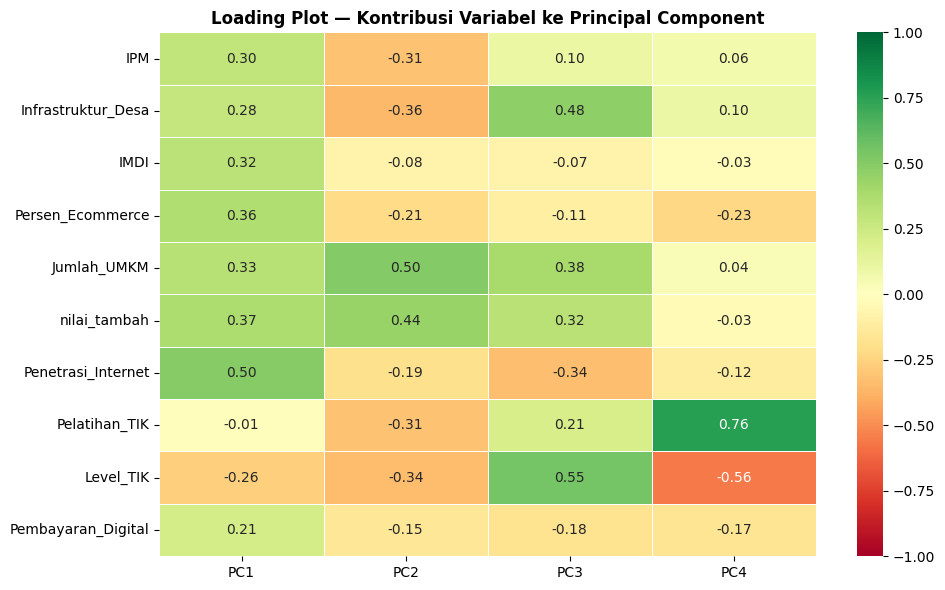

In [24]:
# Buat dataframe loading
feature_names = df_final.drop(columns=['Provinsi']).columns
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print("Loading Matrix (kontribusi variabel ke tiap PC):")
print(loadings.round(3))

# Heatmap loading
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Loading Plot — Kontribusi Variabel ke Principal Component',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

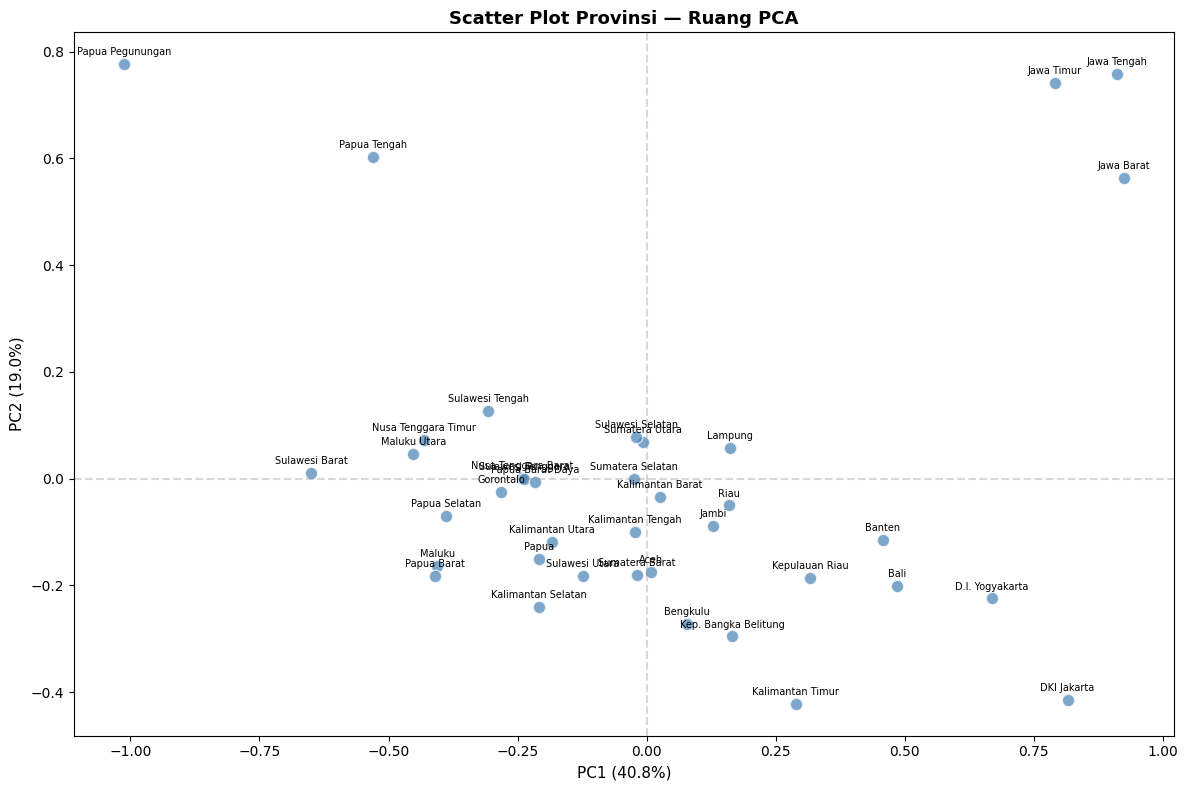

In [25]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c='steelblue', s=80, alpha=0.7, edgecolors='white')

# Tambah label provinsi
for i, prov in enumerate(provinsi_label):
    plt.annotate(prov, (X_pca[i, 0], X_pca[i, 1]),
                 fontsize=7, ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
plt.title('Scatter Plot Provinsi — Ruang PCA', fontsize=13, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()